# Merge Lineage

**Example: MERGE Statement Lineage Tracking**


This example demonstrates how clgraph tracks column lineage through
MERGE INTO statements (UPSERT operations).

Key features demonstrated:
1. MERGE INTO parsing
2. Match condition column tracking
3. UPDATE action lineage
4. INSERT action lineage
5. Export format with MERGE metadata

### Imports

In [1]:
from clgraph import JSONExporter, Pipeline, RecursiveLineageBuilder


def example_simple_merge():
    """
    Basic example: Simple MERGE with UPDATE and INSERT.
    """
    print("=" * 60)
    print("Example 1: Simple MERGE Statement")
    print("=" * 60)

    sql = """
    MERGE INTO customers c
    USING updates u ON c.customer_id = u.customer_id
    WHEN MATCHED THEN UPDATE SET c.name = u.name, c.email = u.email
    WHEN NOT MATCHED THEN INSERT (customer_id, name, email) VALUES (u.customer_id, u.name, u.email)
    """

    builder = RecursiveLineageBuilder(sql, dialect="postgres")
    graph = builder.build()

    print(f"\nQuery:\n{sql}")
    print("\nLineage Edges:")

    for edge in graph.edges:
        line = f"  {edge.from_node.full_name} -> {edge.to_node.full_name}"
        if edge.is_merge_operation:
            line += f" [MERGE {edge.merge_action}]"
        print(line)


def example_merge_with_conditions():
    """
    Example: MERGE with conditional UPDATE.
    """
    print("\n" + "=" * 60)
    print("Example 2: MERGE with Conditional UPDATE")
    print("=" * 60)

    sql = """
    MERGE INTO inventory i
    USING shipments s ON i.product_id = s.product_id
    WHEN MATCHED AND s.quantity > 0 THEN UPDATE SET i.stock = i.stock + s.quantity
    WHEN NOT MATCHED THEN INSERT (product_id, stock) VALUES (s.product_id, s.quantity)
    """

    builder = RecursiveLineageBuilder(sql, dialect="postgres")
    graph = builder.build()

    print(f"\nQuery:\n{sql}")
    print("\nMERGE Operation Edges:")

    for edge in graph.edges:
        if edge.is_merge_operation:
            print(f"  {edge.from_node.full_name} -> {edge.to_node.full_name}")
            print(f"    Action: {edge.merge_action}")
            if edge.merge_condition:
                print(f"    Condition: {edge.merge_condition}")


def example_merge_pipeline():
    """
    Example: MERGE lineage through Pipeline API.
    """
    print("\n" + "=" * 60)
    print("Example 3: MERGE in Pipeline")
    print("=" * 60)

    sql = """
    MERGE INTO target t
    USING source s ON t.id = s.id
    WHEN MATCHED THEN UPDATE SET t.value = s.new_value
    WHEN NOT MATCHED THEN INSERT (id, value) VALUES (s.id, s.new_value)
    """

    pipeline = Pipeline([("merge_op", sql)], dialect="postgres")

    print(f"\nQuery:\n{sql}")
    print("\nMERGE operation edges in pipeline:")

    for edge in pipeline.column_graph.edges:
        if getattr(edge, "is_merge_operation", False):
            print(f"  {edge.from_node.full_name} -> {edge.to_node.full_name}")
            print(f"    Action: {edge.merge_action}")


def example_merge_export():
    """
    Example: Export MERGE lineage to JSON.
    """
    print("\n" + "=" * 60)
    print("Example 4: Export MERGE Lineage")
    print("=" * 60)

    sql = """
    MERGE INTO target t
    USING source s ON t.id = s.id
    WHEN MATCHED THEN UPDATE SET t.value = s.new_value
    """

    pipeline = Pipeline([("merge_op", sql)], dialect="postgres")

    # Export to JSON
    exporter = JSONExporter()
    export_data = exporter.export(pipeline)

    print(f"\nQuery:\n{sql}")
    print("\nExported edges with MERGE metadata:")

    import json

    for edge in export_data.get("edges", []):
        if edge.get("is_merge_operation"):
            print(json.dumps(edge, indent=2))


if __name__ == "__main__":
    example_simple_merge()
    example_merge_with_conditions()
    example_merge_pipeline()
    example_merge_export()

    print("\n" + "=" * 60)
    print("MERGE Statement Lineage Examples Complete!")
    print("=" * 60)

Example 1: Simple MERGE Statement

Query:

    MERGE INTO customers c
    USING updates u ON c.customer_id = u.customer_id
    WHEN MATCHED THEN UPDATE SET c.name = u.name, c.email = u.email
    WHEN NOT MATCHED THEN INSERT (customer_id, name, email) VALUES (u.customer_id, u.name, u.email)
    

Lineage Edges:
  updates.customer_id -> main.customer_id [MERGE match]
  updates.name -> main.name [MERGE update]
  updates.email -> main.email [MERGE update]
  updates.customer_id -> main.customer_id [MERGE insert]
  updates.name -> main.name [MERGE insert]
  updates.email -> main.email [MERGE insert]

Example 2: MERGE with Conditional UPDATE

Query:

    MERGE INTO inventory i
    USING shipments s ON i.product_id = s.product_id
    WHEN MATCHED AND s.quantity > 0 THEN UPDATE SET i.stock = i.stock + s.quantity
    WHEN NOT MATCHED THEN INSERT (product_id, stock) VALUES (s.product_id, s.quantity)
    

MERGE Operation Edges:
  shipments.product_id -> main.product_id
    Action: match
  invento

### Visualize Pipeline Lineage

Display the simplified column lineage for MERGE statement queries.

MERGE Pipeline - Simplified Lineage:


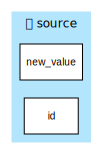

In [2]:
import shutil

from clgraph import visualize_pipeline_lineage

# Create pipeline for visualization
sql_merge = """
MERGE INTO target t
USING source s ON t.id = s.id
WHEN MATCHED THEN UPDATE SET t.value = s.new_value
WHEN NOT MATCHED THEN INSERT (id, value) VALUES (s.id, s.new_value)
"""
merge_pipeline = Pipeline([("merge_op", sql_merge)], dialect="postgres")

if shutil.which("dot") is None:
    print("⚠️  Graphviz not installed. Install with: brew install graphviz")
else:
    print("MERGE Pipeline - Simplified Lineage:")
    display(visualize_pipeline_lineage(merge_pipeline.column_graph.to_simplified()))

## Condition Column Lineage (Gaps 3, 9, 10)

MERGE statements have two kinds of upstream dependencies for assigned target columns:

- **Value dependencies** — the RHS of `SET` (e.g., `t.end_time = current_timestamp()`)
- **Condition dependencies** — columns in `WHEN MATCHED AND (...)` or literal-bound `ON` predicates (e.g., `t.is_active = 'Y'`)

clgraph now tracks both, distinguishing them via `merge_column_role` on each edge:
- `None` — ON clause match columns (equi-join pairs)
- `"value"` — SET assignment RHS columns
- `"condition"` — WHEN guard or ON literal filter columns

### Example 5: SCD2 MERGE — Condition Columns as Dependencies

In a Slowly Changing Dimension Type 2 pattern, the WHEN MATCHED condition determines
*which rows get closed*. The columns in that condition (`name`, `city`, `email`) are
gating dependencies of the assigned columns (`end_time`, `is_active`).

In [3]:
scd2_sql = """
MERGE INTO dim_customer t
USING staging_customer_latest s ON t.id = s.id AND t.is_active = 'Y'
WHEN MATCHED AND (t.name <> s.name OR t.city <> s.city OR t.email <> s.email) THEN
  UPDATE SET t.end_time = current_timestamp(), t.is_active = 'N'
"""

builder = RecursiveLineageBuilder(scd2_sql, dialect="databricks")
graph = builder.build()

print("SCD2 MERGE — All lineage edges with roles:\n")
for edge in sorted(graph.edges, key=lambda e: (e.to_node.column_name, e.merge_column_role or "")):
    if edge.is_merge_operation:
        role = edge.merge_column_role or "match"
        print(f"  {edge.from_node.full_name:>35s}  ->  {edge.to_node.column_name:<12s}  [{role}]")

SCD2 MERGE — All lineage edges with roles:

                   dim_customer.email  ->  end_time      [condition]
        staging_customer_latest.email  ->  end_time      [condition]
                    dim_customer.name  ->  end_time      [condition]
         staging_customer_latest.name  ->  end_time      [condition]
                    dim_customer.city  ->  end_time      [condition]
         staging_customer_latest.city  ->  end_time      [condition]
           staging_customer_latest.id  ->  id            [match]
               dim_customer.is_active  ->  is_active     [condition]
                   dim_customer.email  ->  is_active     [condition]
        staging_customer_latest.email  ->  is_active     [condition]
                    dim_customer.name  ->  is_active     [condition]
         staging_customer_latest.name  ->  is_active     [condition]
                    dim_customer.city  ->  is_active     [condition]
         staging_customer_latest.city  ->  is_active     [condi

### Example 6: Impact Analysis — "What breaks if `staging.name` changes?"

Condition edges make impact analysis complete. Without them, `end_time` would appear
to have *no* upstream column dependency (since `current_timestamp()` has none).
With condition edges, we can see that changes to `name`, `city`, or `email` affect
which rows get their `end_time` updated.

In [4]:
print("Impact analysis: What does end_time depend on?\n")
for edge in graph.edges:
    if edge.is_merge_operation and edge.to_node.column_name == "end_time":
        role = edge.merge_column_role or "match"
        print(f"  {edge.from_node.full_name:<40s}  role={role}")

print("\n---")
print("\nImpact analysis: What does is_active depend on?\n")
for edge in graph.edges:
    if edge.is_merge_operation and edge.to_node.column_name == "is_active":
        role = edge.merge_column_role or "match"
        print(f"  {edge.from_node.full_name:<40s}  role={role}")

Impact analysis: What does end_time depend on?

  dim_customer.email                        role=condition
  staging_customer_latest.email             role=condition
  dim_customer.name                         role=condition
  staging_customer_latest.name              role=condition
  dim_customer.city                         role=condition
  staging_customer_latest.city              role=condition

---

Impact analysis: What does is_active depend on?

  dim_customer.is_active                    role=condition
  dim_customer.email                        role=condition
  staging_customer_latest.email             role=condition
  dim_customer.name                         role=condition
  staging_customer_latest.name              role=condition
  dim_customer.city                         role=condition
  staging_customer_latest.city              role=condition


### Example 7: ON Clause Literal Filter (Gap 9)

The `ON t.is_active = 'Y'` literal predicate is now tracked as a `merge_match_filter`
edge, distinct from the column-column `merge_match` edge for `t.id = s.id`.

In [5]:
print("ON clause edges:\n")
for edge in graph.edges:
    if edge.is_merge_operation and edge.edge_type in ("merge_match", "merge_match_filter"):
        print(
            f"  {edge.from_node.full_name:<35s}  type={edge.edge_type:<20s}  role={edge.merge_column_role}"
        )

ON clause edges:

  staging_customer_latest.id           type=merge_match           role=None
  dim_customer.is_active               type=merge_match_filter    role=condition


### Example 8: JSON Export with `merge_column_role`

The `merge_column_role` field appears in JSON exports, allowing downstream tools
to filter or weight condition vs value dependencies differently.

In [6]:
import json

scd2_pipeline = Pipeline([("scd2_close", scd2_sql)], dialect="databricks")
export_data = JSONExporter().export(scd2_pipeline)

print("Condition edges in JSON export:\n")
for edge in export_data.get("edges", []):
    if edge.get("merge_column_role") == "condition":
        print(json.dumps(edge, indent=2))
        print()

Condition edges in JSON export:

{
  "from_column": "staging_customer_latest.is_active",
  "to_column": "scd2_close:subq:main.is_active",
  "edge_type": "merge_match_filter",
  "transformation": "merge_match_filter",
  "query_id": "scd2_close",
  "is_merge_operation": true,
  "merge_action": "match",
  "merge_condition": null,
  "merge_column_role": "condition"
}

{
  "from_column": "staging_customer_latest.email",
  "to_column": "scd2_close:subq:main.end_time",
  "edge_type": "merge_update",
  "transformation": "merge_update",
  "query_id": "scd2_close",
  "is_merge_operation": true,
  "merge_action": "update",
  "merge_condition": "(t.name <> s.name OR t.city <> s.city OR t.email <> s.email)",
  "merge_column_role": "condition"
}

{
  "from_column": "staging_customer_latest.email",
  "to_column": "scd2_close:subq:main.end_time",
  "edge_type": "merge_update",
  "transformation": "merge_update",
  "query_id": "scd2_close",
  "is_merge_operation": true,
  "merge_action": "update",
  "m